In [2]:
import tensorflow as tf
import numpy as np
import os


In [3]:
print(tf.__version__)

2.21.0


In [4]:
import kagglehub
from pathlib import Path

c:\Users\benke\OneDrive\Desktop\Projekt Wirtschaftsinformatik\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
data_dir = Path(r"c:\Users\benke\Downloads\archive\Fruit And Vegetable Diseases Dataset")

print(data_dir.exists())
print(list(data_dir.iterdir())[:10])

True
[WindowsPath('c:/Users/benke/Downloads/archive/Fruit And Vegetable Diseases Dataset/Apple_Data'), WindowsPath('c:/Users/benke/Downloads/archive/Fruit And Vegetable Diseases Dataset/Banana__Healthy'), WindowsPath('c:/Users/benke/Downloads/archive/Fruit And Vegetable Diseases Dataset/Banana__Rotten'), WindowsPath('c:/Users/benke/Downloads/archive/Fruit And Vegetable Diseases Dataset/Bellpepper__Healthy'), WindowsPath('c:/Users/benke/Downloads/archive/Fruit And Vegetable Diseases Dataset/Bellpepper__Rotten'), WindowsPath('c:/Users/benke/Downloads/archive/Fruit And Vegetable Diseases Dataset/Carrot__Healthy'), WindowsPath('c:/Users/benke/Downloads/archive/Fruit And Vegetable Diseases Dataset/Carrot__Rotten'), WindowsPath('c:/Users/benke/Downloads/archive/Fruit And Vegetable Diseases Dataset/Cucumber__Healthy'), WindowsPath('c:/Users/benke/Downloads/archive/Fruit And Vegetable Diseases Dataset/Cucumber__Rotten'), WindowsPath('c:/Users/benke/Downloads/archive/Fruit And Vegetable Disease

In [6]:
from pathlib import Path
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Resizing,
    Rescaling,
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense
)

#Pfad zum Ordner (habe unterordner für nur äpflel erstellt)
data_dir = Path(r"c:/Users/benke/Downloads/archive/Fruit And Vegetable Diseases Dataset/Apple_Data")

img_size = (64, 64)
batch_size = 32
seed = 42

# 70 % Training 15 % val 15 % test
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.3,
    subset="training",
    seed=seed,
    image_size=img_size,
    batch_size=batch_size
)

temp_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.3,
    subset="validation",
    seed=seed,
    image_size=img_size,
    batch_size=batch_size
)

class_names = train_ds.class_names

temp_batches = temp_ds.cardinality().numpy()
val_batches = temp_batches // 2
val_ds = temp_ds.take(val_batches)
test_ds = temp_ds.skip(val_batches)

print("Klassen:", class_names)
print("Training Batches:", train_ds.cardinality().numpy())
print("Validation Batches:", val_ds.cardinality().numpy())
print("Test Batches:", test_ds.cardinality().numpy())

Found 5363 files belonging to 2 classes.
Using 3755 files for training.
Found 5363 files belonging to 2 classes.
Using 1608 files for validation.
Klassen: ['Apple__Healthy', 'Apple__Rotten']
Training Batches: 118
Validation Batches: 25
Test Batches: 26


In [7]:
model = Sequential()

model.add(Resizing(64, 64))
model.add(Rescaling(1/255.0))

model.add(Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(64, 64, 3)))
model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
model.add(MaxPooling2D((2, 2)))

model.add(Conv2D(32, (3, 3), activation='relu', padding='same'))
model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
model.add(MaxPooling2D((2, 2)))

model.add(Flatten())
model.add(Dense(256, activation='relu'))

# 2 Klassen: Apple__Healthy und Apple__Rotten
model.add(Dense(2, activation='softmax'))

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()


c:\Users\benke\OneDrive\Desktop\Projekt Wirtschaftsinformatik\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resizing (Resizing)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [8]:
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ModelCheckpoint
es=EarlyStopping(patience=3)
mc=ModelCheckpoint(filepath='bestModel.keras',save_best_only=True)

In [9]:
mc=ModelCheckpoint(filepath='bestModel.keras',save_best_only=True)
model.fit(train_ds,validation_data=val_ds,epochs=10, callbacks=[es,mc])

Epoch 1/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 35s 277ms/step - accuracy: 0.7936 - loss: 0.4413 - val_accuracy: 0.8612 - val_loss: 0.3361
Epoch 2/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 36s 231ms/step - accuracy: 0.8735 - loss: 0.3009 - val_accuracy: 0.8975 - val_loss: 0.2266
Epoch 3/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 27s 229ms/step - accuracy: 0.9111 - loss: 0.2209 - val_accuracy: 0.9175 - val_loss: 0.2175
Epoch 4/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 27s 228ms/step - accuracy: 0.9246 - loss: 0.1793 - val_accuracy: 0.9388 - val_loss: 0.1612
Epoch 5/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 26s 223ms/step - accuracy: 0.9470 - loss: 0.1339 - val_accuracy: 0.9325 - val_loss: 0.1732
Epoch 6/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 28s 240ms/step - accuracy: 0.9545 - loss: 0.1246 - val_accuracy: 0.9625 - val_loss: 0.1132
Epoch 7/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 30s 255ms/step - accuracy: 0.9635 - loss: 0.0917 - val_accuracy: 0.9625 - val_loss: 0.0993
Epoch 8/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 31s 261ms/step - accuracy: 0.9707 - loss: 0

In [10]:
model.load_weights('bestModel.keras')
score = model.evaluate(test_ds)

26/26 ━━━━━━━━━━━━━━━━━━━━ 3s 85ms/step - accuracy: 0.9678 - loss: 0.0997


In [12]:
!python -m pip install scikit-learn

  Using cached scikit_learn-1.8.0-cp313-cp313-win_amd64.whl.metadata (11 kB)
  Using cached scipy-1.17.1-cp313-cp313-win_amd64.whl.metadata (60 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.8.0-cp313-cp313-win_amd64.whl (8.0 MB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached scipy-1.17.1-cp313-cp313-win_amd64.whl (36.5 MB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)



[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = model.predict(images)
    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred, target_names=class_names))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 310ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step
[[338

[[338   7]
 [ 12 451]]


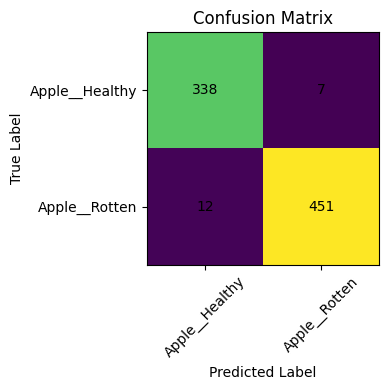

In [15]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(y_true, y_pred)

print(cm)

plt.figure(figsize=(5, 4))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(np.arange(len(class_names)), class_names, rotation=45)
plt.yticks(np.arange(len(class_names)), class_names)

for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()